# Figure S7 — classifying lifestyle from microbiome profiles

| Panel | Content |
| --- | --- |
| **a** | Leave-studies-out ROC curves, with the permuted-label null as an inset |
| **b** | Per-study mean abundance of two of the strongest features, by lifestyle |
| **c** | The twenty most important features, coloured by their prevalence in Westernized samples |
| **d** | Accuracy of a classifier trained to predict the *study* a sample came from |

A random forest is trained on CLR-transformed SGB abundances to separate Westernized from
non-Westernized samples. The cross-validation holds out **whole studies**, not random samples: a
model that memorised study-specific quirks would still score well on held-out samples of a study it
had seen, and would fail here. Panel a is that result; its inset is the same procedure after the
lifestyle labels have been shuffled between studies, which is the null the AUC should be read
against.

Panel d is the complementary worry from the other side. If the profiles carry a strong study
signature, a classifier should be able to recover which study a sample came from — and it does,
well above the majority-class baseline. So batch structure exists; the point of the leave-studies-out
design in panel a is that the lifestyle signal survives it.

## 0. Setup

The two cross-validation runs are the slow part and are cached to JSON. Delete the files to rerun.

In [1]:
import json
import os
import random

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

DATA = '../data'
METADATA = f'{DATA}/nw_metadata.tsv'
PROFILES = f'{DATA}/nw_profiles.tsv'
FEATURE_IMPORTANCES = f'{DATA}/nw_classifier_feature_importances.tsv'   # written by section 6

CACHE_CV = './leave_k_studies_out_results.json'
CACHE_CV_PERMUTED = './leave_k_studies_out_results_perm.json'

SEED = 42
MIN_AGE = 16
EXCLUDED_STUDIES = ['HanniganGD_2017']
MIN_SAMPLES_PER_STUDY = 50     # a study must have this many samples of a lifestyle to be held out
N_ITERATIONS = 30              # random study splits
N_TREES = 50
TOP_FEATURES = 20

# Studies too small or too lifestyle-skewed to use in the per-study panels.
SMALL_STUDIES = ['Obregon-TitoAJ_2015', 'RampelliS_2015']

W_COLOR = '#397797'
NW_COLOR = '#d5d53e'
ROC_COLOR = 'tab:blue'

# Panel features, named as in the figure. The profiles still carry the older Prevotella names for
# the SGBs that have since been moved to Segatella, so the display names are mapped here.
DISPLAY_NAMES = {
    'Prevotella copri clade C (SGB1644)': 'Segatella sinensis (SGB1644)',
    'Prevotella copri clade B (SGB1636_group)': 'Segatella brasiliensis (SGB1636_group)',
    'Prevotella copri clade D (SGB1653)': 'Segatella sinica (SGB1653)',
    'Prevotella copri clade E (SGB1613)': 'Segatella brunsvicensis (SGB1613)',
    'Prevotella copri clade A (SGB1617_group)': 'Segatella hominis (SGB1617_group)',
}
PANEL_B_FEATURES = ['Prevotella copri clade C (SGB1644)',
                    'Dysosmobacter welbionis (SGB15078)']

sns.set_theme(context='paper', style='ticks', font='DejaVu Sans')
mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold',
    'legend.frameon': False, 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

random.seed(SEED)
np.random.seed(SEED)

## 1. Data

Adults only, one malformed age value and `HanniganGD_2017` excluded. The ancient samples are not
used by the classifier at all, so unlike the other notebooks they are not carried along here.

In [2]:
metadata = pd.read_table(METADATA)
metadata['age'] = pd.to_numeric(metadata['age'], errors='coerce')   # one malformed value -> NaN

adults_metadata = metadata[(metadata['age'] > MIN_AGE)
                           & (~metadata['study_name'].isin(EXCLUDED_STUDIES))].copy()
adults_metadata = adults_metadata.set_index('sample_id', drop=False)

print(f'{len(adults_metadata):,} adult samples')
adults_metadata['non_westernized'].value_counts()

6,863 adult samples


no     5661
yes    1202
Name: non_westernized, dtype: int64

In [3]:
def read_sgb_profiles(path):
    """SGB-level rows of a merged MetaPhlAn table, labelled 'Species name (SGBid)'."""
    table = pd.read_table(path, index_col=0)
    table = table.loc[['t__' in clade for clade in table.index]]
    table.index = [clade.split('|')[-2][3:].replace('_', ' ') + ' (' + clade.split('|')[-1][3:] + ')'
                   for clade in table.index]
    return table


sgb_abundances = read_sgb_profiles(PROFILES)

adults_abundances = sgb_abundances[[s for s in adults_metadata.index
                                    if s in sgb_abundances.columns]]
adults_abundances = adults_abundances.loc[adults_abundances.sum(axis=1) > 0].T   # samples x SGBs
adults_abundances = adults_abundances.loc[adults_abundances.sum(axis=1) > 0]
adults_metadata = adults_metadata.loc[adults_abundances.index]

print(f'{adults_abundances.shape[0]:,} samples x {adults_abundances.shape[1]:,} SGBs')

6,861 samples x 4,080 SGBs


## 2. Preparing the model input

Abundances are CLR transformed: each value becomes the log of its ratio to the sample's geometric
mean, which removes the constraint that every profile sums to 100 and stops a change in one abundant
taxon moving every other feature.

A study can only be held out if it has enough samples of a lifestyle to score an AUC on, which is
what `eligible_w` and `eligible_nw` record.

In [5]:
def clr(values, pseudocount=1e-6):
    """Centred log-ratio transform of a samples x features matrix."""
    shifted = values + pseudocount
    geometric_mean = np.exp(np.log(shifted).mean(axis=1, keepdims=True))
    return np.log(shifted / geometric_mean)


def prepare_data_for_predictions(abundances, metadata, label_column='non_westernized'):
    """CLR features, binary labels, and the studies big enough to hold out."""
    aligned = metadata.loc[abundances.index]
    labels = aligned[label_column].map({'no': 0, 'yes': 1}).to_numpy()

    counts = aligned.groupby('study_name')[label_column].value_counts().unstack(fill_value=0)
    eligible_w = list(counts.index[counts.get('no', 0) > MIN_SAMPLES_PER_STUDY])
    eligible_nw = list(counts.index[counts.get('yes', 0) > MIN_SAMPLES_PER_STUDY])

    print(f'n Westernized = {(labels == 0).sum():,}, n non-Westernized = {(labels == 1).sum():,}')
    print(f'{len(eligible_w)} eligible W studies, {len(eligible_nw)} eligible NW studies')
    return clr(abundances.values), labels, aligned, eligible_w, eligible_nw


X, y, filtered_metadata, eligible_w, eligible_nw = prepare_data_for_predictions(
    adults_abundances, adults_metadata)

n Westernized = 5,661, n non-Westernized = 1,200
22 eligible W studies, 9 eligible NW studies


## 3. Leave-studies-out cross-validation

Each iteration holds out a random half of the eligible Westernized studies and the same number of
non-Westernized ones, trains on everything else, and scores the held-out samples. Holding out half
at a time rather than one study is deliberate: with a single study held out the model still has every
other cohort of that lifestyle to lean on, so the test is too easy.

The permuted run shuffles the lifestyle label **between studies**, keeping every sample of a study on
the same side. Shuffling sample by sample would leave each study's lifestyle recoverable from its
neighbours and understate the null.

In [6]:
def eval_leave_k_studies_out(X, y, metadata, eligible_w, eligible_nw, k, n_iters=N_ITERATIONS,
                             seed=SEED):
    """Hold out k studies per lifestyle, train on the rest, score the held-out samples."""
    rng = random.Random(seed)
    results = []
    for iteration in range(n_iters):
        held_out = (rng.sample(eligible_w, min(k, len(eligible_w)))
                    + rng.sample(eligible_nw, min(k, len(eligible_nw))))
        validation = metadata['study_name'].isin(held_out).to_numpy()

        classifier = RandomForestClassifier(n_estimators=N_TREES, class_weight='balanced',
                                            random_state=iteration, n_jobs=-1)
        classifier.fit(X[~validation], y[~validation])
        probabilities = classifier.predict_proba(X[validation])[:, 1]

        results.append({
            'iteration': iteration + 1,
            'held_out': held_out,
            'auc': roc_auc_score(y[validation], probabilities),
            'y_true': y[validation].tolist(),
            'y_proba': probabilities.tolist(),
            'feature_importances': classifier.feature_importances_.tolist(),
        })
    return results


def cached_cv(path, **kwargs):
    if os.path.exists(path):
        with open(path) as handle:
            return json.load(handle)
    results = eval_leave_k_studies_out(**kwargs)
    with open(path, 'w') as handle:
        json.dump(results, handle)
    return results


k_studies = max(3, len(eligible_w) // 2)
results = cached_cv(CACHE_CV, X=X, y=y, metadata=filtered_metadata, eligible_w=eligible_w,
                    eligible_nw=eligible_nw, k=k_studies)

print(f'{len(results)} iterations holding out {k_studies} studies per lifestyle')
print(f"mean AUC = {np.mean([r['auc'] for r in results]):.2f}")

30 iterations holding out 11 studies per lifestyle
mean AUC = 0.96


In [7]:
def permute_labels_between_studies(metadata, seed=SEED):
    """Reassign each study's lifestyle label at random, keeping the number of studies per label."""
    rng = np.random.default_rng(seed)
    study_labels = metadata.groupby('study_name')['non_westernized'].first()
    shuffled = rng.permutation(study_labels.to_numpy())

    permuted = metadata.copy()
    permuted['non_westernized'] = permuted['study_name'].map(dict(zip(study_labels.index, shuffled)))
    agreement = (permuted['non_westernized'] == metadata['non_westernized']).mean()
    print(f'{agreement:.1%} of samples kept their original label by chance')
    return permuted


permuted_metadata = permute_labels_between_studies(filtered_metadata)
X_perm, y_perm, filtered_perm, eligible_w_perm, eligible_nw_perm = prepare_data_for_predictions(
    adults_abundances, permuted_metadata)

results_permuted = cached_cv(CACHE_CV_PERMUTED, X=X_perm, y=y_perm, metadata=filtered_perm,
                             eligible_w=eligible_w_perm, eligible_nw=eligible_nw_perm,
                             k=max(3, len(eligible_w_perm) // 2))

print(f"permuted mean AUC = {np.mean([r['auc'] for r in results_permuted]):.2f}")

75.9% of samples kept their original label by chance
n Westernized = 5,486, n non-Westernized = 1,375
23 eligible W studies, 8 eligible NW studies
permuted mean AUC = 0.56


## 4. Panel a — the ROC curves

Each thin line is one iteration; the thick line is the mean true-positive rate interpolated onto a
common false-positive-rate grid, with one standard deviation shaded. The inset is the permuted run
drawn the same way, on the same axes limits.

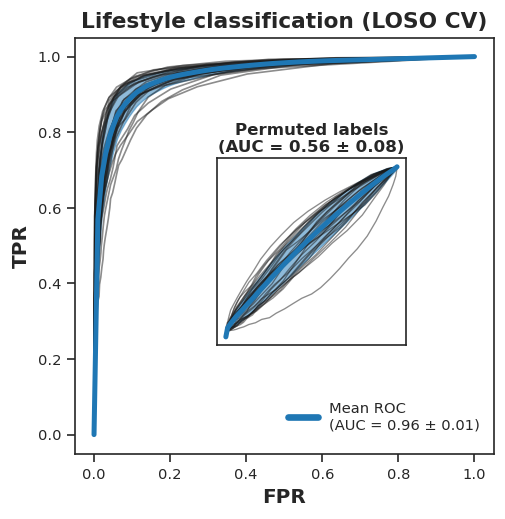

In [9]:
def roc_summary(results, grid=np.linspace(0, 1, 100)):
    """Per-iteration curves plus the interpolated mean and spread."""
    curves, aucs = [], []
    for result in results:
        fpr, tpr, _ = roc_curve(np.array(result['y_true']), np.array(result['y_proba']))
        aucs.append(auc(fpr, tpr))
        interpolated = np.interp(grid, fpr, tpr)
        interpolated[0] = 0.0
        curves.append((fpr, tpr, interpolated))
    stacked = np.vstack([curve[2] for curve in curves])
    return curves, stacked.mean(axis=0), stacked.std(axis=0), np.mean(aucs), np.std(aucs)


def plot_roc(ax, results, grid=np.linspace(0, 1, 100), label=None, thin_width=1):
    curves, mean_tpr, std_tpr, mean_auc, std_auc = roc_summary(results, grid)
    for fpr, tpr, _ in curves:
        ax.plot(fpr, tpr, color='k', lw=thin_width, alpha=0.5)
    ax.fill_between(grid, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1),
                    color=ROC_COLOR, alpha=0.5)
    ax.plot(grid, mean_tpr, color=ROC_COLOR, lw=3, label=label)
    return mean_auc, std_auc


fig, ax = plt.subplots(figsize=(4.5, 4.5))
mean_auc, std_auc = plot_roc(ax, results)
ax.legend(handles=[plt.Line2D([], [], color=ROC_COLOR, lw=4,
                              label=f'Mean ROC\n(AUC = {mean_auc:.2f} ± {std_auc:.2f})')],
          loc='lower right', bbox_to_anchor=(1.0, 0.02))
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Lifestyle classification (LOSO CV)')

inset = ax.inset_axes([0.34, 0.26, 0.45, 0.45])
perm_auc, perm_std = plot_roc(inset, results_permuted, thin_width=0.8)
inset.set_xticks([])
inset.set_yticks([])
inset.set_title(f'Permuted labels\n(AUC = {perm_auc:.2f} ± {perm_std:.2f})', fontsize=10, pad=4)
plt.show()

## 5. Panel b — two features, by study

Rather than one point per sample, each study contributes its mean abundance, which keeps a single
large cohort from dominating the picture. The two small studies in `SMALL_STUDIES` are dropped,
since a mean over a handful of samples is noise.

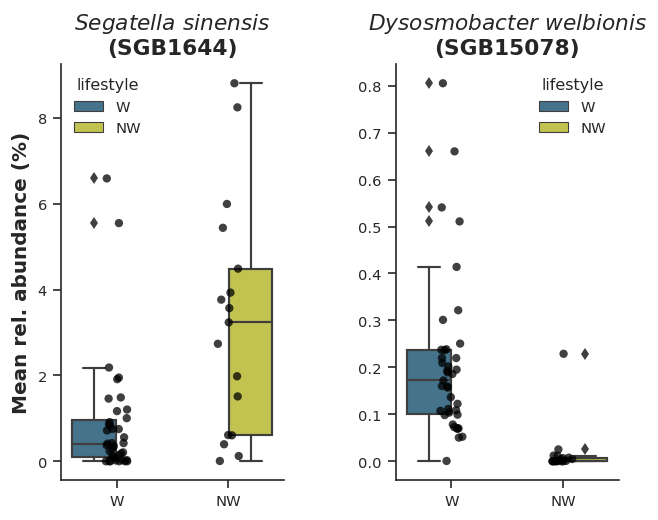

In [11]:
study_lifestyle = (filtered_metadata.groupby('study_name')['non_westernized'].first()
                   .drop(labels=SMALL_STUDIES, errors='ignore'))

study_means = (adults_abundances.join(filtered_metadata['study_name'])
               .groupby('study_name').mean())
study_means = study_means.loc[study_lifestyle.index]

fig, axes = plt.subplots(1, 2, figsize=(6, 4.5), gridspec_kw={'wspace': 0.5})
for ax, feature in zip(axes, PANEL_B_FEATURES):
    panel = pd.DataFrame({'abundance': study_means[feature],
                          'lifestyle': study_lifestyle.map({'no': 'W', 'yes': 'NW'})})
    sns.boxplot(data=panel, x='lifestyle', y='abundance', order=['W', 'NW'], hue='lifestyle',
                hue_order=['W', 'NW'], palette={'W': W_COLOR, 'NW': NW_COLOR},
                linewidth=1.3, flierprops={'marker': 'd', 'markersize': 5,
                                           'markerfacecolor': '#3f3f3f',
                                           'markeredgecolor': 'none'}, ax=ax)
    sns.stripplot(data=panel, x='lifestyle', y='abundance', order=['W', 'NW'], color='black',
                  alpha=0.75, size=5, ax=ax)

    name, sgb = DISPLAY_NAMES.get(feature, feature).rsplit(' (', 1)
    italic = '$\\it{' + name.replace(' ', '\\ ') + '}$'
    ax.set_title(italic + '\n(' + sgb[:-1] + ')')
    ax.set_xlabel('')
    ax.set_ylabel('Mean rel. abundance (%)' if ax is axes[0] else '')
sns.despine()
plt.show()

## 6. Panel c — feature importance

Importances are averaged over the cross-validation iterations, so the error bar is the spread across
held-out study splits rather than within one forest. The colour is each SGB's prevalence in
Westernized samples, which is what separates a feature the model uses because it is nearly always
present on one side from one it uses because it is nearly always absent.

In [12]:
importances = np.array([result['feature_importances'] for result in results])
feature_importance = pd.DataFrame({
    'sgb_id': adults_abundances.columns,
    'mean_fi': importances.mean(axis=0),
    'std_fi': importances.std(axis=0),
}).sort_values('mean_fi', ascending=False).reset_index(drop=True)
feature_importance.insert(0, 'fi_rank', feature_importance.index)

presence = (adults_abundances > 0).astype(int)
presence['lifestyle'] = filtered_metadata['non_westernized']
prevalence = presence.groupby('lifestyle').mean()
feature_importance['prev_in_w'] = feature_importance['sgb_id'].map(prevalence.loc['no'])
feature_importance['prev_in_nw'] = feature_importance['sgb_id'].map(prevalence.loc['yes'])

feature_importance.to_csv(FEATURE_IMPORTANCES, sep='\t', index=False)
feature_importance.head(TOP_FEATURES)

,fi_rank,sgb_id,mean_fi,std_fi,prev_in_w,prev_in_nw
0,0,Prevotella copri clade C (SGB1644),0.020312,0.015069,0.141848,0.787500
1,1,Dysosmobacter welbionis (SGB15078),0.019110,0.010102,0.862392,0.123333
2,2,Clostridium phoceensis (SGB15154),0.014904,0.007911,0.794383,0.064167
3,3,Prevotella copri clade D (SGB1636_group),0.014123,0.012572,0.069952,0.665833
4,4,Prevotella SGB1653 (SGB1653),0.013700,0.009256,0.056350,0.603333
5,5,GGB9597 SGB15022 (SGB15022),0.013640,0.009312,0.107225,0.609167
6,6,Prevotella hominis (SGB1617_group),0.012951,0.009166,0.065183,0.620000
7,7,Dysosmobacter sp NSJ 60 (SGB15124),0.012759,0.009046,0.666313,0.084167
8,8,Clostridiaceae bacterium (SGB4269),0.012582,0.008050,0.908320,0.482500
9,9,Prevotella copri clade B (SGB1613),0.012548,0.009430,0.103692,0.659167


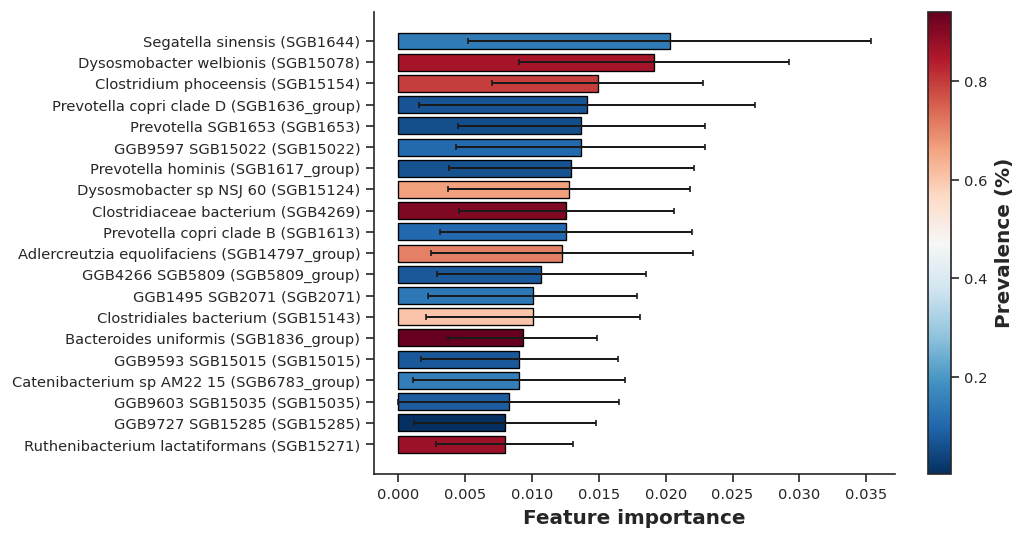

In [13]:
top = feature_importance.head(TOP_FEATURES).copy()
top['label'] = top['sgb_id'].map(lambda name: DISPLAY_NAMES.get(name, name))

norm = mcolors.Normalize(vmin=top['prev_in_w'].min(), vmax=top['prev_in_w'].max())
colormap = plt.cm.RdBu_r

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top['label'], top['mean_fi'], xerr=top['std_fi'],
        color=[colormap(norm(value)) for value in top['prev_in_w']],
        edgecolor='black', capsize=2)
ax.invert_yaxis()                                  # most important at the top
ax.set_xlabel('Feature importance')

colorbar = fig.colorbar(plt.cm.ScalarMappable(cmap=colormap, norm=norm), ax=ax)
colorbar.set_label('Prevalence (%)', fontweight='bold')
sns.despine()
plt.show()

## 7. Panel d — can the profiles predict the study?

A random forest trained on the same features to predict `study_name`, scored with stratified 5-fold
cross-validation over samples. The baseline is the share of samples belonging to the largest study,
which is what a classifier that always guessed that study would score.

This one does **not** hold out studies, by construction — the question is whether study identity is
recoverable at all.

In [14]:
study_samples = filtered_metadata[~filtered_metadata['study_name'].isin(SMALL_STUDIES)].index
study_X = clr(adults_abundances.loc[study_samples].values)
study_y = LabelEncoder().fit_transform(filtered_metadata.loc[study_samples, 'study_name'])

baseline = filtered_metadata.loc[study_samples, 'study_name'].value_counts(normalize=True).max()

scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1,
                           random_state=SEED),
    study_X, study_y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='accuracy', n_jobs=-1)

statistic, pvalue = ttest_1samp(scores, baseline)
print(f'{len(np.unique(study_y))} studies, {len(study_samples):,} samples')
print(f'accuracy {scores.mean():.3f} ± {scores.std():.3f}, baseline {baseline:.3f}, '
      f'p = {pvalue:.3g}')

56 studies, 6,791 samples
accuracy 0.627 ± 0.008, baseline 0.167, p = 4.27e-08


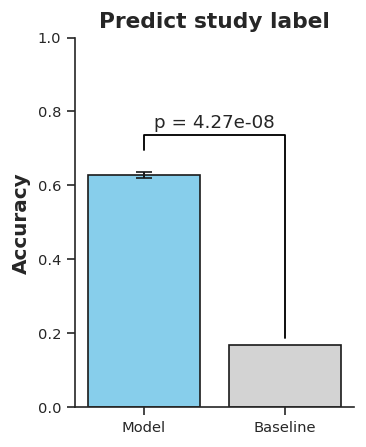

In [15]:
fig, ax = plt.subplots(figsize=(3, 4))
ax.bar(0, scores.mean(), yerr=scores.std(), capsize=5, color='skyblue', edgecolor='k',
       linewidth=1, width=0.8)
ax.bar(1, baseline, color='lightgray', edgecolor='k', linewidth=1, width=0.8)

height = max(scores.mean() + scores.std(), baseline)
ax.plot([0, 0, 1, 1], [height + 0.06, height + 0.1, height + 0.1, baseline + 0.02],
        lw=1.1, color='black')
ax.text(0.5, height + 0.11, f'p = {pvalue:.2e}', ha='center', va='bottom', fontsize=11)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Model', 'Baseline'])
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Predict study label')
sns.despine()
plt.show()